# Scenario 5 — 170 km / 10 GBaud

Full performance-vs-complexity figure: received effective SNR (peak over power)
vs complexity [RM/2D] for **EDC, Ideal DBP, OSSFM, LDBP, ESSFM, L-ESSFM**,
at **n=1.125 (solid)** and **n=2 (dashed)**.

Run the cells in order using the **l_essfm_torch** Python environment.
The shared forward and each model are loaded when available, otherwise generated
and saved. With `RETRAIN=False`, existing coefficients are preserved. Evaluated
SNR curves are also cached, with fingerprints of the forward, config, coefficients
and evaluator source, so subsequent runs can redraw the figures without simulation.

The 10-GBaud forward uses 5 WDM channels spaced by 11 GHz, 20 powers from 0 to
1.9 dBm, and one realization. Missing ESSFM/L-ESSFM models train at 1 dBm
instead of the 9-dBm default inherited by the old training configuration.
LDBP retains its separate -2-dBm training setting. Existing coefficients
are reused unchanged; loading them does not retrain them at a new power.
ESSFM keeps the optimized splitting ratio used in notebook 01.
LDBP complexity uses the actual saved filter lengths, including incomplete pruning.

In [1]:
import sys, os
from pathlib import Path
# Resolve the project from its root or any directory below it.
_ROOT = next((str(p) for p in (Path.cwd(), *Path.cwd().parents)
              if (p / 'core/system.py').is_file() and
                 (p / 'config/scenario_170km_10GBd.ini').is_file()), None)
if _ROOT is None:
    raise RuntimeError('Open this notebook from the l_essfm project or its notebooks directory.')
sys.path.insert(0, os.path.join(_ROOT, 'core')); os.chdir(_ROOT)
import numpy as np
import matplotlib.pyplot as plt
from system import build_system
from backprop import curve
from complexity import eval_compl, eval_compl_time, complexity_ldbp

SCENARIO = 'scenario_170km_10GBd'
RESDIR   = f'results/{SCENARIO}'
L_KM, R_GBD = 170e3, 10e9
CFG  = {1.125: f'config/{SCENARIO}.ini', 2.0: 'config/scenario_170km_10GBd_n2.ini'}
NS_FULL = [1,2,3,4,5,6,7,8,9,10]   # n=1.125
NS_RED  = [1,5,10]                 # n=2 (reduced)

# RETRAIN: if a method's parameters.csv is missing (or RETRAIN=True), the helpers
# below TRAIN it from scratch with the PyTorch trainer (core/train.py, dual-pol)
# and save it under RESDIR. With RETRAIN=False and the coefficients present, the
# notebook just loads them and simulates (fast, no GPU training).
RETRAIN = False
TRAIN_POWER_DBM = 1.0   # operating region of this 10-GBaud WDM scenario
LDBP_TRAIN_POWER_DBM = -2.0   # preserve the existing single-pol LDBP training setting
LDBP_NS = 2           # total DBP steps (one physical span)
os.makedirs(RESDIR, exist_ok=True)

# fast training config (Gaussian, short 1024-sym blocks) derived from the scenario
def _train_cfg(nos):
    import re
    base = CFG[nos]
    out = f'config/_train_{SCENARIO}_n{"2" if nos==2.0 else "1125"}.ini'
    s = open(base).read()
    s = s.replace('data symbols per block = 262144', 'data symbols per block = 1024')
    s = re.sub(r'(?m)^modulation = .*', 'modulation = Gaussian', s)
    open(out, 'w').write(s); return out

## 1. Load or generate the shared forward

In [2]:
# Forward for this scenario: local .npy under l_essfm/forward/ (generated ONCE, reused).
# Loads the cached forward if present; otherwise runs the forward SSFM to produce it
# (same Watt-keyed dict format as the other scenarios) and saves it before continuing.
from system import forward
FWD_PATH = f'forward/forward_{SCENARIO}.npy'
if os.path.exists(FWD_PATH):
    fwd = np.load(FWD_PATH, allow_pickle=True).item()
    print(f'loaded cached forward propagation: {FWD_PATH}')
else:
    print(f'no cache at {FWD_PATH}; generating forward propagation data ...', flush=True)
    Sfwd = build_system(CFG[1.125])            # forward physics is n-independent
    Pdbm_grid = np.arange(0.0, 2.0, 0.1)
    NREAL = 1
    np.random.seed(12345)
    fwd = {}
    for Pdb in Pdbm_grid:
        Pw = 10**(Pdb/10) * 1e-3
        reals = []
        for _ in range(NREAL):
            y, x = forward(Sfwd, Pw)
            reals.append((y.astype(np.complex64), x.astype(np.complex64)))
        fwd[float(Pw)] = reals
        print(f'  P={Pdb:.2f} dBm done', flush=True)
    os.makedirs(os.path.dirname(FWD_PATH), exist_ok=True)
    np.save(FWD_PATH, np.array(fwd, dtype=object))
    print(f'saved {FWD_PATH}')

data = {round(10*np.log10(Pw/1e-3), 4): [(np.asarray(y), np.asarray(x)) for (y, x) in r] for Pw, r in fwd.items()}
Pgrid = np.array(sorted(data))
print(f'{len(Pgrid)} powers available in {FWD_PATH}')

# Both oversamplings reuse the same analog forward.
for nos, cfg in CFG.items():
    Scheck = build_system(cfg)
    for reals in data.values():
        for y, x in reals:
            if y.shape != (Scheck['Npol'], Scheck['Nsamp_a']) or x.shape != (Scheck['Npol'], Scheck['Nsym']):
                raise ValueError(f'Forward cache shapes do not match {cfg}. Check the scenario before regenerating.')
del Scheck


loaded cached forward propagation: forward/forward_scenario_170km_10GBd.npy
20 powers available in forward/forward_scenario_170km_10GBd.npy


## 2. Helpers: peak SNR for a method at given Ns and oversampling

In [3]:
import hashlib, json

def _file_digest(path):
    h = hashlib.sha256()
    with open(path, 'rb') as handle:
        for block in iter(lambda: handle.read(1024 * 1024), b''):
            h.update(block)
    return h.hexdigest()

# Hash once per run; small config/parameter files are checked at each call.
_FORWARD_DIGEST = _file_digest(FWD_PATH)
_EVALUATOR_DIGEST = {
    p.name: _file_digest(p) for p in sorted(Path('core').glob('*.py'))
}
CURVEDIR = Path(RESDIR) / 'curves'
CURVEDIR.mkdir(parents=True, exist_ok=True)
_TRAINING_CACHE_KEY = None

def _cached_curve(label, cfg, params, compute):
    """Load a matching effSNR curve; compute and save only on a cache miss."""
    signature = {
        'version': 1, 'label': label, 'forward': _FORWARD_DIGEST,
        'config': _file_digest(cfg), 'parameters': _file_digest(params) if params else None,
        'evaluator': _EVALUATOR_DIGEST, 'powers_dbm': Pgrid.tolist(),
    }
    fingerprint = hashlib.sha256(json.dumps(signature, sort_keys=True).encode()).hexdigest()
    path = CURVEDIR / (label + '.npz')
    if path.exists():
        with np.load(path, allow_pickle=False) as saved:
            if str(saved['fingerprint']) == fingerprint:
                values = saved['snr'].copy()
                if values.shape == Pgrid.shape and np.all(np.isfinite(values)):
                    print(f'  loaded {label}', flush=True)
                    return values
    print(f'  evaluating {label} ...', flush=True)
    values = np.asarray(compute(), dtype=float)
    if values.shape != Pgrid.shape or not np.all(np.isfinite(values)):
        raise ValueError(f'{label}: expected one finite effSNR value per launch power.')
    temporary = path.with_suffix('.tmp.npz')
    np.savez(temporary, fingerprint=fingerprint, Pgrid=Pgrid, snr=values,
             provenance=json.dumps(signature, sort_keys=True))
    os.replace(temporary, path)
    return values

def peak(nos, kind, ns, params=None, edc=False):
    S = build_system(CFG[nos])
    label = f'{Path(params).parent.name if params else kind}_n{nos}_Ns{ns}_edc{edc}'
    return _cached_curve(label, CFG[nos], params,
                         lambda: curve(S, data, Pgrid, kind, ns, params, edc=edc)).max()

def lessfm_peak(nos, tag, ns):
    """Peak SNR for L-ESSFM/ESSFM at (nos, ns). Loads parameters.csv if present;
    if missing (or RETRAIN), trains it with the PyTorch dual-pol trainer and saves.
    ESSFM uses the optimized splitting ratio of the single-span notebook 01."""
    suff = '' if nos == 1.125 else '_n2'
    p = f'{RESDIR}/{tag}{suff}_Ns{ns}/parameters.csv'
    if RETRAIN or not os.path.exists(p):
        from train import train_lessfm, train_essfm, clear_forward_cache
        global _TRAINING_CACHE_KEY
        train_cfg = _train_cfg(nos)
        training_key = (_file_digest(train_cfg), TRAIN_POWER_DBM)
        if training_key != _TRAINING_CACHE_KEY:
            clear_forward_cache()  # invalidate across scenarios, reuse across models
            _TRAINING_CACHE_KEY = training_key
        Strain = build_system(train_cfg)
        print(f'  training {tag} n={nos} Ns={ns} ...', flush=True)
        if tag == 'essfm':
            train_essfm(Strain, ns, p, opt_rho=True, P_dbm=TRAIN_POWER_DBM)
        else:
            train_lessfm(Strain, ns, p, P_dbm=TRAIN_POWER_DBM)
    return peak(nos, 'lessfm', ns, p)

## 3. References: EDC, Ideal DBP (both n)

In [4]:
# Keep the existing 100-step reference for this single-span scenario.
# EDC compensates dispersion on the shared forward.
edc      = peak(1.125, 'edc', 1, edc=True)            # EDC: same SNR at both n
ideal125 = peak(1.125, 'ideal', 100)
ideal2   = peak(2.0,   'ideal', 100)
print(f'EDC {edc:.3f} dB | Ideal n=1.125 DBP {ideal125:.3f} dB | Ideal n=2 DBP {ideal2:.3f} dB')


  evaluating edc_n1.125_Ns1_edcTrue ...
  evaluating ideal_n1.125_Ns100_edcFalse ...
  evaluating ideal_n2.0_Ns100_edcFalse ...
EDC 19.454 dB | Ideal n=1.125 DBP 19.498 dB | Ideal n=2 DBP 19.541 dB


## 4. L-ESSFM and ESSFM, both oversamplings

In [5]:
lessfm125 = {ns: lessfm_peak(1.125,'lessfm',ns) for ns in NS_FULL}
lessfm125 = {k:v for k,v in lessfm125.items() if v is not None}
essfm125  = {ns: lessfm_peak(1.125,'essfm', ns) for ns in NS_FULL}
essfm125  = {k:v for k,v in essfm125.items() if v is not None}
lessfm2   = {ns: lessfm_peak(2.0,'lessfm',ns) for ns in NS_FULL}
lessfm2   = {k:v for k,v in lessfm2.items() if v is not None}
essfm2    = {ns: lessfm_peak(2.0,'essfm', ns) for ns in NS_FULL}
essfm2    = {k:v for k,v in essfm2.items() if v is not None}
print('L-ESSFM n=1.125:', {k:round(v,3) for k,v in lessfm125.items()})
print('L-ESSFM n=2   :', {k:round(v,3) for k,v in lessfm2.items()})

print('ESSFM n=1.125:', {k:round(v,3) for k,v in essfm125.items()})
print('ESSFM n=2    :', {k:round(v,3) for k,v in essfm2.items()})


  evaluating lessfm_Ns1_n1.125_Ns1_edcFalse ...
  evaluating lessfm_Ns2_n1.125_Ns2_edcFalse ...
  evaluating lessfm_Ns3_n1.125_Ns3_edcFalse ...
  evaluating lessfm_Ns4_n1.125_Ns4_edcFalse ...
  evaluating lessfm_Ns5_n1.125_Ns5_edcFalse ...
  evaluating lessfm_Ns6_n1.125_Ns6_edcFalse ...
  evaluating lessfm_Ns7_n1.125_Ns7_edcFalse ...
  evaluating lessfm_Ns8_n1.125_Ns8_edcFalse ...
  evaluating lessfm_Ns9_n1.125_Ns9_edcFalse ...
  evaluating lessfm_Ns10_n1.125_Ns10_edcFalse ...
  evaluating essfm_Ns1_n1.125_Ns1_edcFalse ...
  evaluating essfm_Ns2_n1.125_Ns2_edcFalse ...
  evaluating essfm_Ns3_n1.125_Ns3_edcFalse ...
  evaluating essfm_Ns4_n1.125_Ns4_edcFalse ...
  evaluating essfm_Ns5_n1.125_Ns5_edcFalse ...
  evaluating essfm_Ns6_n1.125_Ns6_edcFalse ...
  evaluating essfm_Ns7_n1.125_Ns7_edcFalse ...
  evaluating essfm_Ns8_n1.125_Ns8_edcFalse ...
  evaluating essfm_Ns9_n1.125_Ns9_edcFalse ...
  evaluating essfm_Ns10_n1.125_Ns10_edcFalse ...
  evaluating lessfm_n2_Ns1_n2.0_Ns1_edcFalse .

## 5. OSSFM (both n) and LDBP (n=2, pruning sweep)

In [6]:
from system import make_bw
ossfm125 = {ns: peak(1.125, 'ossfm', ns) for ns in NS_FULL}
ossfm125 = {k:v for k,v in ossfm125.items() if v is not None}
ossfm2 = {ns: peak(2.0, 'ossfm', ns) for ns in NS_FULL}
ossfm2 = {k:v for k,v in ossfm2.items() if v is not None}
print('OSSFM n=1.125:', {k:round(v,3) for k,v in ossfm125.items()})
print('OSSFM n=2   :', {k:round(v,3) for k,v in ossfm2.items()})

def _ldbp_cfg(logarithmic=True):
    import re
    s = open(CFG[2.0]).read()
    s = s.replace('data symbols per block = 262144', 'data symbols per block = 1024')
    s = re.sub(r'(?m)^modulation = .*', 'modulation = Gaussian', s)
    if logarithmic:
        s = re.sub(r'(?m)^step size method = .*', 'step size method = logarithmic', s)
    out = f'config/_ldbp_train_{SCENARIO}.ini'; open(out, 'w').write(s); return out

def _ldbp_cfg_eval(logarithmic=True):
    import re
    s = open(CFG[2.0]).read()
    s = re.sub(r'(?m)^modulation = .*', 'modulation = Gaussian', s)
    if logarithmic:
        s = re.sub(r'(?m)^step size method = .*', 'step size method = logarithmic', s)
    out = f'config/_ldbp_eval_{SCENARIO}.ini'; open(out, 'w').write(s); return out

from ldbp_eval import load_ldbp_params, ldbp_backprop
LDBP_EVAL_CFG = _ldbp_cfg_eval()
S_eval = build_system(LDBP_EVAL_CFG) 
StPS = LDBP_NS     # one span: steps per span equal total steps
bw_eval = make_bw(S_eval, StPS)

def ldbp_peak(tag, target):
    """target: per-step tap PATTERN (e.g. [17] uniform or [11,9] sawtooth), tiled."""
    p = f'{RESDIR}/ldbp_{tag}/parameters.csv'
    if RETRAIN or not os.path.exists(p):
        from train import train_ldbp
        Strain = build_system(_ldbp_cfg())   # uses 1024 for training (correct)
        M = make_bw(Strain, StPS).model_steps
        print(f'  training LDBP {tag} (init 21 -> {target}, log step) ...', flush=True)
        train_ldbp(Strain, StPS, p, [21]*M, iters=15000, P_dbm=LDBP_TRAIN_POWER_DBM, lr=5e-4,
                   target_taps=target, n_blocks=200)
    cd, nl = load_ldbp_params(p, bw_eval.model_steps)
    # Use the actual filters: older runs may have stopped before pruning finished.
    ldbp_taps[tag] = [len(cd[i]) for i in range(bw_eval.model_steps)]
    snr = _cached_curve(f'ldbp_{tag}_n2_Ns{LDBP_NS}', LDBP_EVAL_CFG, p,
        lambda: [np.mean([ldbp_backprop(S_eval, bw_eval, cd, nl, y, x, 10**(pp/10)*1e-3)
                         for (y, x) in data[pp]]) for pp in Pgrid])
    return max(snr)

# the 5 Fig.1b LDBP points: (tag, target pattern, average taps for complexity)
LDBP_POINTS = [('prune11',[11],11), ('p9',[9],9), ('p7',[7],7),
               ('p5',[5],5), ('v4',[5,3],4)]
ldbp = []
ldbp_taps = {}
for tag, target, avg in LDBP_POINTS:
    # Always call the helper: missing models must be trained, not silently skipped.
    s = ldbp_peak(tag, target)
    actual_avg = float(np.mean(ldbp_taps[tag]))
    nc = (actual_avg - 1) / 2
    ldbp.append((complexity_ldbp(LDBP_NS, nc, 2), s))
    print(f'  LDBP {tag}: target pattern {target}, saved taps {ldbp_taps[tag]}, '
          f'average {actual_avg:.3f}')
ldbp.sort()
print('LDBP points:', [(round(c), round(s,3)) for c, s in ldbp])


  evaluating ossfm_n1.125_Ns1_edcFalse ...
  evaluating ossfm_n1.125_Ns2_edcFalse ...
  evaluating ossfm_n1.125_Ns3_edcFalse ...
  evaluating ossfm_n1.125_Ns4_edcFalse ...
  evaluating ossfm_n1.125_Ns5_edcFalse ...
  evaluating ossfm_n1.125_Ns6_edcFalse ...
  evaluating ossfm_n1.125_Ns7_edcFalse ...
  evaluating ossfm_n1.125_Ns8_edcFalse ...
  evaluating ossfm_n1.125_Ns9_edcFalse ...
  evaluating ossfm_n1.125_Ns10_edcFalse ...
  evaluating ossfm_n2.0_Ns1_edcFalse ...
  evaluating ossfm_n2.0_Ns2_edcFalse ...
  evaluating ossfm_n2.0_Ns3_edcFalse ...
  evaluating ossfm_n2.0_Ns4_edcFalse ...
  evaluating ossfm_n2.0_Ns5_edcFalse ...
  evaluating ossfm_n2.0_Ns6_edcFalse ...
  evaluating ossfm_n2.0_Ns7_edcFalse ...
  evaluating ossfm_n2.0_Ns8_edcFalse ...
  evaluating ossfm_n2.0_Ns9_edcFalse ...
  evaluating ossfm_n2.0_Ns10_edcFalse ...
OSSFM n=1.125: {1: np.float64(19.485), 2: np.float64(19.511), 3: np.float64(19.511), 4: np.float64(19.511), 5: np.float64(19.511), 6: np.float64(19.511), 7: n

## 6. The full Fig. 1b

<05_170km_10GBd cell 7>:46: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


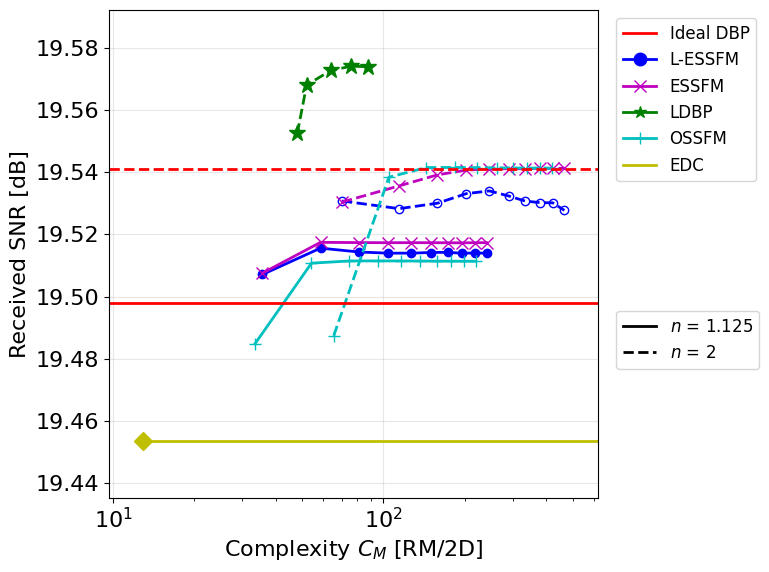

In [7]:
plt.close('all')
C = {'lessfm':'b','essfm':'m','ossfm':'c','ldbp':'g','edc':'y','ideal':'r'}
# OFC/CLEO figure style (matches ldbp2/new_testMAX.ipynb): thick lines, large
# font, big markers, 8x6 canvas.
plt.rcParams['lines.linewidth'] = 2
plt.rcParams['font.size'] = 16
plt.rcParams['lines.markersize'] = 9
fig, ax = plt.subplots(figsize=(8,6))
def cx(d, nos): return [eval_compl(n, nos, L_KM, R_GBD) for n in sorted(d)], [d[n] for n in sorted(d)]
# Keep the comparison convention of notebooks 01-03: frequency-domain
# ESSFM/L-ESSFM and time-domain OSSFM (one coefficient, Nc=0).
def cxt(d, nos): return [eval_compl_time(n, nos, L_KM, R_GBD, 0) for n in sorted(d)], [d[n] for n in sorted(d)]
# L-ESSFM
x,y = cx(lessfm125,1.125); ax.plot(x,y,color=C['lessfm'],ls='-',marker='o',ms=6)
if lessfm2: x,y=cx(lessfm2,2.0); ax.plot(x,y,color=C['lessfm'],ls='--',marker='o',mfc='none',ms=6)
# ESSFM
x,y = cx(essfm125,1.125); ax.plot(x,y,color=C['essfm'],ls='-',marker='x',ms=8)
if essfm2: x,y=cx(essfm2,2.0); ax.plot(x,y,color=C['essfm'],ls='--',marker='x',ms=8)
# OSSFM
x,y = cxt(ossfm125,1.125); ax.plot(x,y,color=C['ossfm'],ls='-',marker='+',ms=9)
x,y = cxt(ossfm2,2.0); ax.plot(x,y,color=C['ossfm'],ls='--',marker='+',ms=9)
# LDBP (n=2)
if ldbp: ax.plot([c for c,_ in ldbp],[s for _,s in ldbp],color=C['ldbp'],ls='--',marker='*',ms=12)
# Ideal + EDC
ax.axhline(ideal125,color=C['ideal'],ls='-'); ax.axhline(ideal2,color=C['ideal'],ls='--')
ax.set_xscale('log')
# Autoscale from this scenario, including the EDC complexity marker.
x0 = eval_compl(0,1.125,L_KM,R_GBD)
ax.plot([x0],[edc],color=C['edc'],marker='D',ms=9)
ax.margins(x=0.08, y=0.15)
costs = [float(v) for line in ax.lines if line.get_transform() == ax.transData
         for v in line.get_xdata()]
xmin, xmax = min(costs), max(costs)
xpad = (xmax / xmin)**0.08 if xmax > xmin else 1.1
ax.set_xlim(xmin / xpad, xmax * xpad)
ax.hlines(edc, x0, ax.get_xlim()[1], color=C['edc'], linestyles='-')
from matplotlib.lines import Line2D
meth=[Line2D([0],[0],color=C['ideal'],label='Ideal DBP'),Line2D([0],[0],color=C['lessfm'],marker='o',label='L-ESSFM'),
      Line2D([0],[0],color=C['essfm'],marker='x',label='ESSFM'),Line2D([0],[0],color=C['ldbp'],marker='*',label='LDBP'),
      Line2D([0],[0],color=C['ossfm'],marker='+',label='OSSFM'),Line2D([0],[0],color=C['edc'],label='EDC')]
sty=[Line2D([0],[0],color='k',ls='-',label='$n$ = 1.125'),Line2D([0],[0],color='k',ls='--',label='$n$ = 2')]
l1=ax.legend(handles=meth,loc='upper left',bbox_to_anchor=(1.02,1),fontsize=12)
ax.add_artist(l1)
ax.legend(handles=sty,loc='upper left',bbox_to_anchor=(1.02,0.40),fontsize=12)
ax.set_xlabel('Complexity $C_M$ [RM/2D]'); ax.set_ylabel('Received SNR [dB]'); ax.grid(True,alpha=0.3)
plt.tight_layout(); plt.savefig(f'{RESDIR}/fig1b.png',dpi=110); plt.savefig(f'{RESDIR}/fig1b.svg'); plt.show()

## 7. Same figure vs number of steps $N_s$

Identical layout, but the x-axis is the number of DBP steps $N_s$ instead of the
complexity. EDC (no DBP steps) and Ideal DBP are horizontal references. LDBP is
shown at its best point (highest saved effSNR) at $N_s$=10.

<05_170km_10GBd cell 8>:33: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


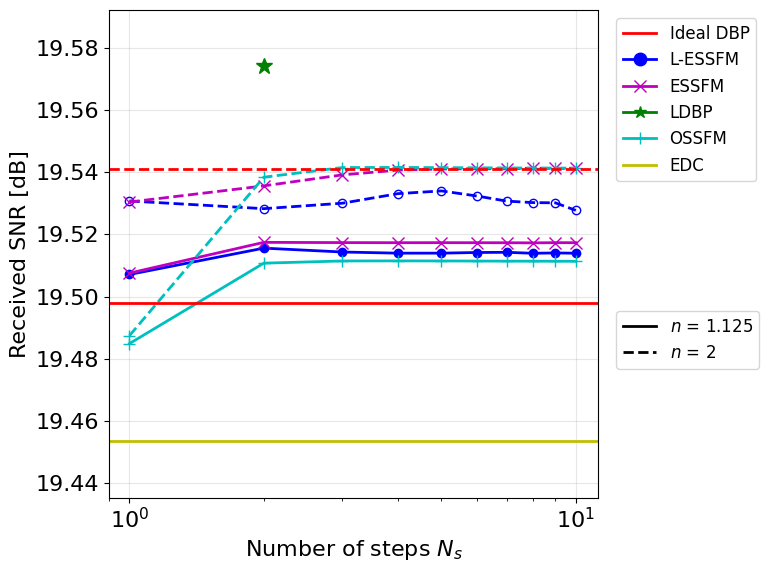

In [8]:
plt.close('all')
plt.rcParams['lines.linewidth'] = 2
plt.rcParams['font.size'] = 16
plt.rcParams['lines.markersize'] = 9
fig, ax = plt.subplots(figsize=(8,6))
# x-axis = number of steps Ns (the dict keys); same OFC/CLEO style as fig1b
def nx(d): return sorted(d), [d[n] for n in sorted(d)]
# L-ESSFM
x,y = nx(lessfm125); ax.plot(x,y,color=C['lessfm'],ls='-',marker='o',ms=6)
if lessfm2: x,y=nx(lessfm2); ax.plot(x,y,color=C['lessfm'],ls='--',marker='o',mfc='none',ms=6)
# ESSFM
x,y = nx(essfm125); ax.plot(x,y,color=C['essfm'],ls='-',marker='x',ms=8)
if essfm2: x,y=nx(essfm2); ax.plot(x,y,color=C['essfm'],ls='--',marker='x',ms=8)
# OSSFM
x,y = nx(ossfm125); ax.plot(x,y,color=C['ossfm'],ls='-',marker='+',ms=9)
x,y = nx(ossfm2); ax.plot(x,y,color=C['ossfm'],ls='--',marker='+',ms=9)
# LDBP (n=2): highest saved effSNR among the tested filters at N_s=LDBP_NS
if ldbp: ax.plot([LDBP_NS],[max(s for _,s in ldbp)],color=C['ldbp'],ls='none',marker='*',ms=12)
# Ideal + EDC: horizontal references (EDC now also horizontal, no DBP steps)
ax.axhline(ideal125,color=C['ideal'],ls='-'); ax.axhline(ideal2,color=C['ideal'],ls='--')
ax.axhline(edc,color=C['edc'],ls='-')
ax.set_xscale('log'); ax.set_xlim(9e-1, ax.get_xlim()[1])
ax.margins(y=0.15)
from matplotlib.lines import Line2D
meth=[Line2D([0],[0],color=C['ideal'],label='Ideal DBP'),Line2D([0],[0],color=C['lessfm'],marker='o',label='L-ESSFM'),
      Line2D([0],[0],color=C['essfm'],marker='x',label='ESSFM'),Line2D([0],[0],color=C['ldbp'],marker='*',label='LDBP'),
      Line2D([0],[0],color=C['ossfm'],marker='+',label='OSSFM'),Line2D([0],[0],color=C['edc'],label='EDC')]
sty=[Line2D([0],[0],color='k',ls='-',label='$n$ = 1.125'),Line2D([0],[0],color='k',ls='--',label='$n$ = 2')]
l1=ax.legend(handles=meth,loc='upper left',bbox_to_anchor=(1.02,1),fontsize=12)
ax.add_artist(l1)
ax.legend(handles=sty,loc='upper left',bbox_to_anchor=(1.02,0.40),fontsize=12)
ax.set_xlabel('Number of steps $N_s$'); ax.set_ylabel('Received SNR [dB]'); ax.grid(True,alpha=0.3)
plt.tight_layout(); plt.savefig(f'{RESDIR}/fig_vs_steps.png',dpi=110); plt.savefig(f'{RESDIR}/fig_vs_steps.svg'); plt.show()